# Examen C11 — Optimización de rutas en grafos

**Caso de negocio:** Red de cajeros automáticos / bancos

**Autor:** Abel Soto

Este notebook **ejecuta** la solución usando el módulo `ejecutable.py` que vive en la
misma carpeta.


## 0) Instalación de dependencias
Idempotente: si ya están, no hace nada.


In [ ]:
# Instala dependencias sólo si faltan.
import importlib, subprocess, sys

REQUIRED = {
    "numpy":      "numpy",
    "pandas":     "pandas",
    "matplotlib": "matplotlib",
    "seaborn":    "seaborn",
    "pytest":     "pytest"
}

missing = []
for mod, pkg in REQUIRED.items():
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(pkg)

if missing:
    print(f"Instalando: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("Todas las dependencias ya están instaladas.")


Todas las dependencias ya están instaladas.


## 1) Imports


In [ ]:
# Importa las clases del módulo del proyecto.
from ejecutable import (
    # generación / costo / grafo
    SyntheticDatasetGenerator,
    CostCalculator,
    GraphBuilder,
    GraphContext,

    # solver (único — basado en el primer solve_route)
    RouteResult,
    RouteSolver,

    # casos
    CaseManager,

    # plots
    SyntheticMapPlotter,
    CaseRoutePlotter,
    RiskHeatmapPlotter,
    
    # paleta
    PALETTE,
)

import numpy as np
import pandas as pd

%matplotlib inline


## 2) Generación del dataset sintético

(semilla 123, grilla 30×30, con un caso borde donde un ATM y un BANCO quedan aislados).


In [3]:
generator = SyntheticDatasetGenerator(
    grid_max_x=30,
    grid_max_y=30,
    seed=123,
    border_cases=True,
    border_nodes=((4, 4), (5, 4)),
)
nodos_df, routes_df, summary = generator.generate()

print("Resumen de generación:")
for k, v in summary.items():
    print(f"  {k}: {v}")


Resumen de generación:
  grid_nodes: 961
  routes_edges: 3660
  nodos_total: 40
  n_atms: 20
  n_bancos: 20
  direction_counts: {'two_way(2)': 2555, 'one_way(+1/-1)': 908, 'blocked(0)': 197}
  direction_shares: {'two_way(2)': 0.6980874316939891, 'one_way(+1/-1)': 0.24808743169398906, 'blocked(0)': 0.05382513661202186}
  border_info: {'atm_border_coord': (4, 4), 'bank_border_coord': (5, 4), 'border_edge_canonical': ((4, 4), (5, 4)), 'blocked_incident_edges_count': 15}


In [4]:
nodos_df.head()

,node_id,status,operativo,x,y,in_grid,case
0,ATM_BORDER,ATM,open,4,4,True,NORMAL
1,ATM_001,ATM,closed,5,8,True,NORMAL
2,ATM_002,ATM,open,19,25,True,NORMAL
3,ATM_003,ATM,open,8,0,True,NORMAL
4,ATM_004,ATM,open,21,7,True,NORMAL


In [5]:
routes_df.head()

,route_id,from_x,from_y,to_x,to_y,direction,riesgo,tiempo,fuel_cost
0,RTE_000001,10,3,11,4,2,1,21,0.034035
1,RTE_000002,7,12,7,13,-1,2,21,0.790260
2,RTE_000003,0,18,1,18,2,0,37,0.629187
3,RTE_000004,14,9,15,8,2,2,34,0.420581
4,RTE_000005,11,5,12,5,2,3,52,0.694727


## 3) Mapa sintético (paleta formal, líneas finas)


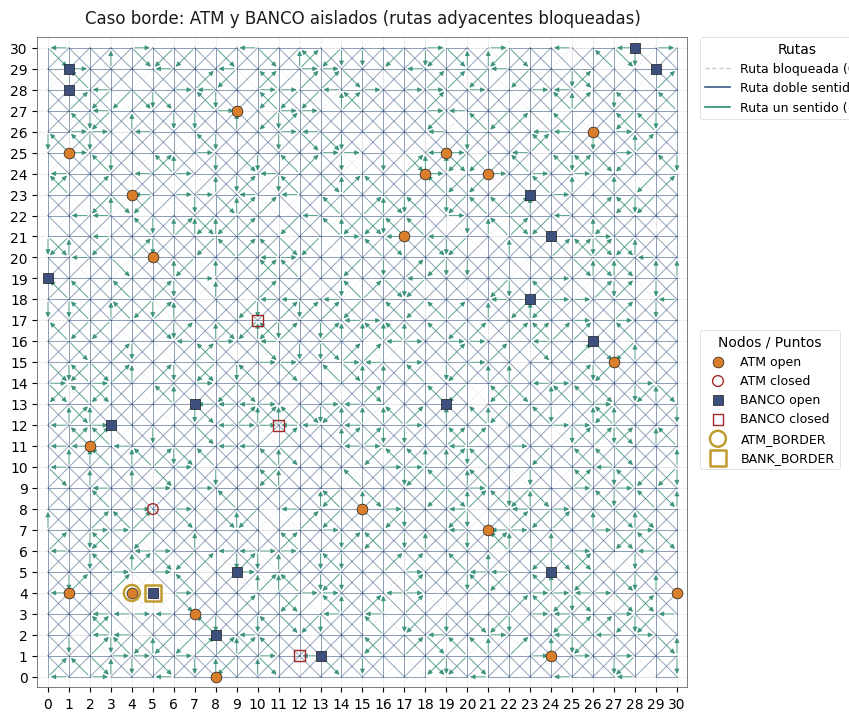

In [6]:
SyntheticMapPlotter(figsize=(11, 11)).plot(
    nodos_df,
    routes_df,
    grid_max_x=30,
    grid_max_y=30,
    show_blocked=True,
    arrows=True,
    title="Caso borde: ATM y BANCO aislados (rutas adyacentes bloqueadas)",
)


## 4) Heatmap de riesgo incidente por nodo


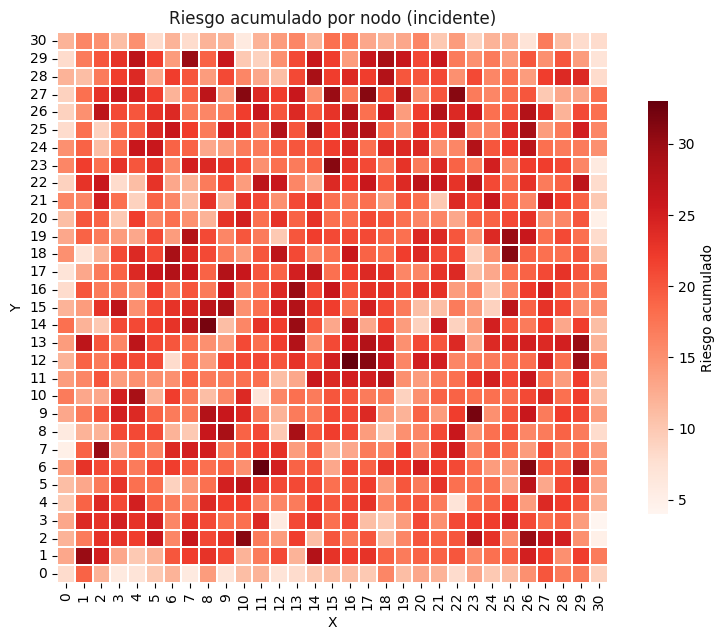

In [7]:
RiskHeatmapPlotter().plot(
    routes_df,
    grid_max_x=30,
    grid_max_y=30,
    title="Riesgo acumulado por nodo (incidente)",
)


## 5) Costo total por arista + grafo dirigido + contexto

- `CostCalculator`  -> aplica pesos lineales + interacciones opcionales.
- `GraphBuilder.build_directed_edges` -> expande según `direction`.
- `GraphContext.from_dataframes` -> construye **una sola vez** el contexto
  (adjacency, edge_set, id2coord, etc.) reutilizable para miles de queries.


In [ ]:
COST_PARAMS = {
    "weights": {
        "tiempo":    1.0,
        "riesgo":    6.0,
        "fuel_cost": 2.0,
    },

    "interactions": 
    [
        {"vars": ("riesgo", "tiempo"), 
         "coef": 0.02, 
         "type": "product"}, # product, min, max
    ],

    "normalize": "none", #maxmin, zscore
}

routes_costed = CostCalculator(COST_PARAMS).compute(routes_df, out_col="total_cost")
directed_edges = GraphBuilder.build_directed_edges(routes_costed)
ctx = GraphContext.from_dataframes(nodos_df, directed_edges, cost_col="total_cost")

print("ATMs abiertos in-grid:",  len(ctx.atms_open_ids))
print("Bancos abiertos in-grid:", len(ctx.banks_open_ids))
print("Total aristas dirigidas:", len(ctx.edges_pool))


ATMs abiertos in-grid: 19
Bancos abiertos in-grid: 17
Total aristas dirigidas: 6018


## 6) Consulta única

Para cargas masivas, el mismo método acepta un `ctx` ya construido - eso es lo
que `CaseManager` hace internamente.


In [9]:
solver = RouteSolver()

result = solver.solve(
    nodes_df=nodos_df,
    directed_edges_df=directed_edges,
    origin_node_id="BANK_001",
    destination_node_id="ATM_010",
    mandatory_edge=((5, 5), (5, 6)),
    mandatory_stops=["ATM_003", "ATM_007"],
    tie_breaker="min_hops",
    audit=True,
)

print("feasible:               ", result.feasible)
print("reason:                 ", result.reason)
print("cost:                   ", result.total_cost)
print("mandatory_edge_in_path: ", result.mandatory_edge_in_path)
print("mandatory_edges_in_path:", result.mandatory_edges_in_path)
print("metrics:                ", result.metrics)


feasible:                True
reason:                  None
cost:                    1635.835268281367
mandatory_edge_in_path:  True
mandatory_edges_in_path: [True]
metrics:                 {'expanded_states': 4624, 'hops': 52, 'runtime_ms': 19.480499999190215, 'n_mandatory_edges': 1}


## 6.b) Extensión punto 6 — **N aristas obligatorias** vía bitmask

El solver soporta una **lista** de aristas obligatorias (`mandatory_edges`) en
lugar de una sola. Internamente el estado es `(coord, k, used_mask)` donde
`used_mask` es un bitmask de N bits; el goal es `used_mask == (1<<N) - 1`.

Verificamos con dos aristas distintas.


In [10]:
# Tomo dos aristas existentes en el grafo
e_a = ((5, 5),  (5, 6))
e_b = ((10, 10), (9, 11))

result_2m = solver.solve(
    ctx=ctx,                                # modo cached (reusa el ctx)
    origin_node_id="BANK_001",
    destination_node_id="ATM_010",
    mandatory_edges=[e_a, e_b],
    tie_breaker="min_hops",
    audit=True,
)

print("feasible:                ", result_2m.feasible)
print("cost:                    ", result_2m.total_cost)
print("mandatory_edge_in_path:  ", result_2m.mandatory_edge_in_path, "(todas)")
print("mandatory_edges_in_path: ", result_2m.mandatory_edges_in_path, "(por arista)")
print("expanded_states:         ", result_2m.metrics["expanded_states"])

# Evidencia: cada arista obligatoria DEBE estar en path_edges
print("\n¿e_a en path_edges?", e_a in result_2m.path_edges)
print("¿e_b en path_edges?", e_b in result_2m.path_edges)


feasible:                 True
cost:                     887.4800378718336
mandatory_edge_in_path:   True (todas)
mandatory_edges_in_path:  [True, True] (por arista)
expanded_states:          3188

¿e_a en path_edges? True
¿e_b en path_edges? True


## 7) Múltiples consultas — `CaseManager` (reusa el `ctx`)


In [11]:
manager = CaseManager(ctx)  # usa RouteSolver por default

cases_df = manager.make_empty_cases_df()

# Caso 0 — solución válida (1 arista obligatoria)
cases_df.loc[len(cases_df)] = {
    "case_id": "MANUAL_001",
    "origin_node_id": "BANK_001", "destination_node_id": "ATM_010",
    "mandatory_from_x": 5, "mandatory_from_y": 5,
    "mandatory_to_x":   5, "mandatory_to_y":   6,
    "mandatory_stops": ["ATM_003", "ATM_007"],
    "forbidden_nodes": [], "forbidden_edges": [],
    "tie_breaker": "min_hops", "audit": True,
    "feasible": None, "total_cost": None, "mandatory_edge_in_path": None,
    "reason": None, "metrics": None, "path_edges": None,
}

# Caso 1 — destino cerrado (debería fallar)
cases_df.loc[len(cases_df)] = {
    "case_id": "MANUAL_002",
    "origin_node_id": "BANK_001", "destination_node_id": "ATM_005",
    "mandatory_from_x": 5, "mandatory_from_y": 5,
    "mandatory_to_x":   5, "mandatory_to_y":   6,
    "mandatory_stops": [], "forbidden_nodes": [], "forbidden_edges": [],
    "tie_breaker": None, "audit": False,
    "feasible": None, "total_cost": None, "mandatory_edge_in_path": None,
    "reason": None, "metrics": None, "path_edges": None,
}

# Caso 2 — arista obligatoria inexistente
cases_df.loc[len(cases_df)] = {
    "case_id": "MANUAL_003",
    "origin_node_id": "BANK_001", "destination_node_id": "ATM_010",
    "mandatory_from_x": 999, "mandatory_from_y": 999,
    "mandatory_to_x":   999, "mandatory_to_y":   1000,
    "mandatory_stops": [], "forbidden_nodes": [], "forbidden_edges": [],
    "tie_breaker": None, "audit": False,
    "feasible": None, "total_cost": None, "mandatory_edge_in_path": None,
    "reason": None, "metrics": None, "path_edges": None,
}

cases_df


,case_id,origin_node_id,destination_node_id,mandatory_from_x,mandatory_from_y,mandatory_to_x,mandatory_to_y,mandatory_stops,forbidden_nodes,forbidden_edges,tie_breaker,audit,feasible,total_cost,mandatory_edge_in_path,reason,metrics,path_edges
0,MANUAL_001,BANK_001,ATM_010,5,5,5,6,"[ATM_003, ATM_007]",[],[],min_hops,True,None,None,None,None,None,None
1,MANUAL_002,BANK_001,ATM_005,5,5,5,6,[],[],[],None,False,None,None,None,None,None,None
2,MANUAL_003,BANK_001,ATM_010,999,999,999,1000,[],[],[],None,False,None,None,None,None,None,None


In [12]:
for idx in cases_df.index:
    res = manager.run_case_by_index(cases_df, idx)
    print(f"[{cases_df.at[idx, 'case_id']}] feasible={res.feasible}  "
          f"cost={res.total_cost}  reason={res.reason}")

cases_df[["case_id", "feasible", "total_cost", "mandatory_edge_in_path", "reason"]]


[MANUAL_001] feasible=True  cost=1635.835268281367  reason=None
[MANUAL_002] feasible=True  cost=436.4721404968361  reason=None
[MANUAL_003] feasible=False  cost=None  reason=MANDATORY_EDGE_MISSING


,case_id,feasible,total_cost,mandatory_edge_in_path,reason
0,MANUAL_001,True,1635.835268,True,None
1,MANUAL_002,True,436.47214,True,None
2,MANUAL_003,False,None,False,MANDATORY_EDGE_MISSING


## 7.b) Caso con DOS aristas obligatorias en `cases_df`

`CaseManager` también acepta una columna opcional `mandatory_edges` (lista de
tuplas) que tiene **prioridad** sobre las columnas legacy de una sola arista.


In [13]:
# Asegurar columnas para el caso multi-arista
for col in ("mandatory_edges", "mandatory_edges_in_path"):
    if col not in cases_df.columns:
        cases_df[col] = None

cases_df.loc[len(cases_df)] = {
    "case_id": "MANUAL_004_MULTI",
    "origin_node_id": "BANK_001", "destination_node_id": "ATM_010",
    # Las columnas singular se ignoran si mandatory_edges está poblada
    "mandatory_from_x": 0, "mandatory_from_y": 0,
    "mandatory_to_x":   0, "mandatory_to_y":   0,
    "mandatory_edges": [((5, 5), (5, 6)), ((10, 10), (9, 11))],
    "mandatory_stops": [],
    "forbidden_nodes": [], "forbidden_edges": [],
    "tie_breaker": "min_hops", "audit": True,
    "feasible": None, "total_cost": None, "mandatory_edge_in_path": None,
    "reason": None, "metrics": None, "path_edges": None,
    "mandatory_edges_in_path": None,
}

idx_multi = cases_df.index[-1]
res_multi = manager.run_case_by_index(cases_df, idx_multi)

print(f"feasible:                {res_multi.feasible}")
print(f"cost:                    {res_multi.total_cost}")
print(f"mandatory_edge_in_path:  {res_multi.mandatory_edge_in_path}")
print(f"mandatory_edges_in_path: {res_multi.mandatory_edges_in_path}")


feasible:                True
cost:                    887.4800378718336
mandatory_edge_in_path:  True
mandatory_edges_in_path: [True, True]


## 8) Visualización de la ruta solución (caso simple)


In [18]:
cases_df

,case_id,origin_node_id,destination_node_id,mandatory_from_x,mandatory_from_y,mandatory_to_x,mandatory_to_y,mandatory_stops,forbidden_nodes,forbidden_edges,tie_breaker,audit,feasible,total_cost,mandatory_edge_in_path,reason,metrics,path_edges,mandatory_edges,mandatory_edges_in_path
0,MANUAL_001,BANK_001,ATM_010,5,5,5,6,"[ATM_003, ATM_007]",[],[],min_hops,True,True,1635.835268,True,None,"{'expanded_states': 4624, 'hops': 52, 'runtime...","[((3, 12), (4, 11)), ((4, 11), (3, 10)), ((3, ...",None,None
1,MANUAL_002,BANK_001,ATM_005,5,5,5,6,[],[],[],None,False,True,436.47214,True,None,"{'expanded_states': 453, 'hops': 14, 'runtime_...","[((3, 12), (4, 11)), ((4, 11), (3, 10)), ((3, ...",None,None
2,MANUAL_003,BANK_001,ATM_010,999,999,999,1000,[],[],[],None,False,False,None,False,MANDATORY_EDGE_MISSING,"{'runtime_ms': 0.012399999832268804, 'bad_edge...",[],None,None
3,MANUAL_004_MULTI,BANK_001,ATM_010,0,0,0,0,[],[],[],min_hops,True,True,887.480038,True,None,"{'expanded_states': 3188, 'hops': 27, 'runtime...","[((3, 12), (4, 11)), ((4, 11), (3, 10)), ((3, ...","[((5, 5), (5, 6)), ((10, 10), (9, 11))]","[True, True]"


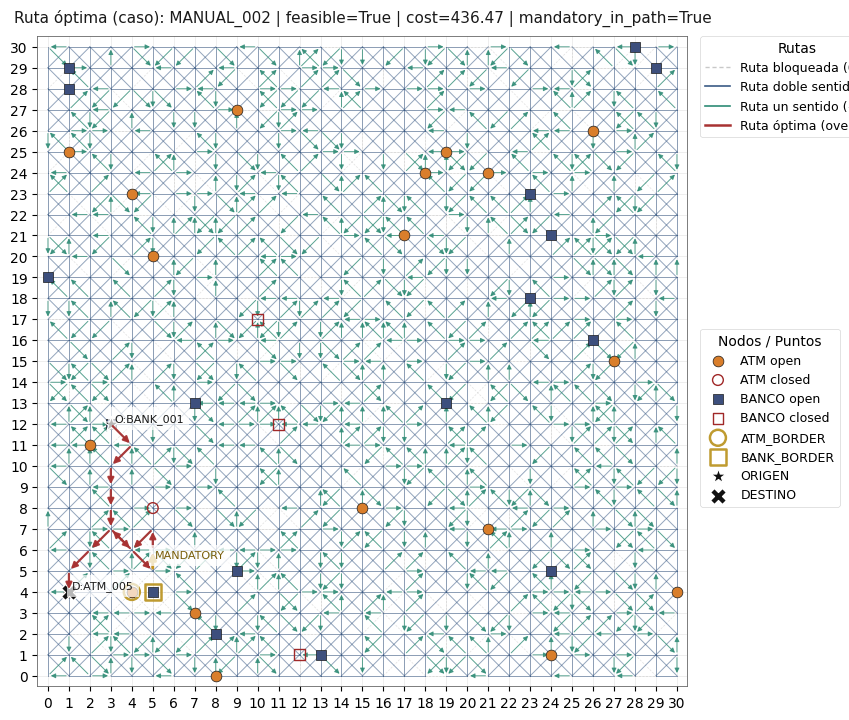

In [19]:
CaseRoutePlotter(figsize=(11, 11)).plot(
    cases_df=cases_df,
    case_id = 'MANUAL_002',
    # case_idx=0,
    nodos_df=nodos_df,
    routes_df=routes_df,
    grid_max_x=30,
    grid_max_y=30,
)


## 9) Escenario de estrés — múltiples consultas sobre el mismo grafo

Mismo `ctx` reutilizado para 10.000 consultas (no se reconstruye el contexto
por-llamada, lo que reproduce el comportamiento del modo "cached" original).


In [15]:
stress_cases_df = manager.generate_stress_cases(
    n_queries=10_000,
    seed=42,
    p_add_stops=0.40,
    max_stops=3,
    p_forbidden=0.10,
    p_infeasible=0.05,
    tie_breaker="min_hops",
)
print(f"Casos de estrés generados: {len(stress_cases_df)}")
stress_cases_df.head()


Casos de estrés generados: 10000


,case_id,origin_node_id,destination_node_id,mandatory_from_x,mandatory_from_y,mandatory_to_x,mandatory_to_y,mandatory_stops,forbidden_nodes,forbidden_edges,tie_breaker,audit,feasible,total_cost,mandatory_edge_in_path,reason,metrics,path_edges
0,STRESS_000000,BANK_003,ATM_BORDER,22,29,21,29,[],[],[],min_hops,False,None,None,None,None,None,None
1,STRESS_000001,BANK_002,ATM_019,9999,9999,9999,10000,[],"[(24, 21), (15, 8)]",[],min_hops,False,None,None,None,None,None,None
2,STRESS_000002,BANK_008,ATM_018,14,29,15,28,[],[],[],min_hops,False,None,None,None,None,None,None
3,STRESS_000003,BANK_015,ATM_011,7,29,6,30,[],[],[],min_hops,False,None,None,None,None,None,None
4,STRESS_000004,BANK_010,ATM_002,27,7,28,7,[],[],[],min_hops,False,None,None,None,None,None,None


In [16]:
manager.run_stress(stress_cases_df, limit=10_000, print_every=2000)


[2000/10000] elapsed=34.63s feasible=1579/2000
[4000/10000] elapsed=81.88s feasible=3140/4000
[6000/10000] elapsed=116.22s feasible=4727/6000
[8000/10000] elapsed=153.58s feasible=6316/8000
[10000/10000] elapsed=195.02s feasible=7877/10000
[DONE] 10000 casos en 195.03s  => 19.50 ms/caso aprox.


,case_id,origin_node_id,destination_node_id,mandatory_from_x,mandatory_from_y,mandatory_to_x,mandatory_to_y,mandatory_stops,forbidden_nodes,forbidden_edges,tie_breaker,audit,feasible,total_cost,mandatory_edge_in_path,reason,metrics,path_edges
0,STRESS_000000,BANK_003,ATM_BORDER,22,29,21,29,[],[],[],min_hops,False,False,None,False,NO_FEASIBLE_PATH,"{'expanded_states': 1910, 'runtime_ms': 13.020...",[]
1,STRESS_000001,BANK_002,ATM_019,9999,9999,9999,10000,[],"[(24, 21), (15, 8)]",[],min_hops,False,False,None,False,MANDATORY_EDGE_MISSING,"{'runtime_ms': 0.023100001271814108, 'bad_edge...",[]
2,STRESS_000002,BANK_008,ATM_018,14,29,15,28,[],[],[],min_hops,False,True,1523.776084,True,None,"{'expanded_states': 2100, 'hops': 42, 'runtime...","[((29, 29), (28, 29)), ((28, 29), (27, 28)), (..."
3,STRESS_000003,BANK_015,ATM_011,7,29,6,30,[],[],[],min_hops,False,True,998.406124,True,None,"{'expanded_states': 1215, 'hops': 26, 'runtime...","[((23, 18), (22, 19)), ((22, 19), (22, 20)), (..."
4,STRESS_000004,BANK_010,ATM_002,27,7,28,7,[],[],[],min_hops,False,True,1404.91265,True,None,"{'expanded_states': 2382, 'hops': 41, 'runtime...","[((7, 13), (7, 12)), ((7, 12), (8, 11)), ((8, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,STRESS_009995,BANK_004,ATM_009,24,23,24,22,[],[],[],min_hops,False,True,961.486394,True,None,"{'expanded_states': 1846, 'hops': 26, 'runtime...","[((26, 16), (25, 17)), ((25, 17), (24, 18)), (..."
9996,STRESS_009996,BANK_011,ATM_012,19,4,18,5,"[ATM_010, ATM_011]",[],[],min_hops,False,True,1711.696645,True,None,"{'expanded_states': 4650, 'hops': 48, 'runtime...","[((13, 1), (14, 1)), ((14, 1), (15, 2)), ((15,..."
9997,STRESS_009997,BANK_012,ATM_014,9,19,9,18,[],[],[],min_hops,False,True,815.437102,True,None,"{'expanded_states': 931, 'hops': 24, 'runtime_...","[((24, 5), (23, 6)), ((23, 6), (22, 7)), ((22,..."
9998,STRESS_009998,BANK_012,ATM_018,6,17,7,18,[],[],[],min_hops,False,True,1188.393771,True,None,"{'expanded_states': 2063, 'hops': 37, 'runtime...","[((24, 5), (23, 6)), ((23, 6), (22, 5)), ((22,..."


In [17]:
n_total = len(stress_cases_df)
n_feas = int(stress_cases_df["feasible"].fillna(False).sum())
print(f"Feasibles: {n_feas} / {n_total} ({100*n_feas/n_total:.1f}%)")

print("\nRazones de fracaso (top):")
print(stress_cases_df.loc[stress_cases_df["feasible"] == False, "reason"].value_counts())


Feasibles: 7877 / 10000 (78.8%)

Razones de fracaso (top):
reason
NO_FEASIBLE_PATH                            1479
MANDATORY_EDGE_MISSING                       556
MANDATORY_EDGE_ENDPOINT_OOB_OR_CLOSED         84
REACHED_DEST_BUT_MANDATORY_EDGE_NOT_USED       4
Name: count, dtype: int64
